# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

## LOADING THE DATASET

In [2]:
# creating database connection
conn = sqlite3.connect('inventory.db')

# fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,580320,15245006.40,284098.0,10203839.02,1345638.62,521998.40,137203.36,-5041167.38,-49.404615,0.489554,0.669323
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,656152,15216164.88,320494.0,9638146.98,1123024.74,588877.32,289858.48,-5578017.90,-57.874381,0.488445,0.633415
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,749628,13673214.72,374280.0,9076241.20,922280.30,687708.14,247560.44,-4596973.52,-50.648428,0.499288,0.663797
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,806728,13044791.76,400824.0,8951945.76,840100.02,736485.60,514064.14,-4092846.00,-45.720183,0.496851,0.686247
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,552436,12092824.04,271676.0,8446215.24,1091556.56,499175.66,514064.14,-3646608.80,-43.174472,0.491778,0.698449


# Exploratory Data Analysis

- Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [5]:
# summary satistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,21384.0,1.065065e+04,18753.080628,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,21384.0,1.803923e+04,12661.890990,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,21384.0,2.438530e+01,109.266819,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,21384.0,3.564367e+01,148.242550,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,21384.0,8.473605e+02,664.293678,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,21384.0,1.256355e+04,44379.309314,4.00,144.000000,1048.000000,7903.000000,1.350640e+06
TotalPurchaseDollars,21384.0,1.204268e+05,492259.687566,2.84,1813.830000,14621.860000,82952.980000,1.524501e+07
TotalSalesQuantity,21384.0,6.154964e+03,21905.190553,0.00,66.000000,522.000000,3858.500000,6.698780e+05
TotalSalesDollars,21384.0,8.447815e+04,335302.691289,0.00,1458.440000,10596.090000,56793.830000,1.020384e+07
TotalSalesPrice,21384.0,3.758757e+04,89903.444480,0.00,579.420000,5715.600000,32119.125000,1.345639e+06


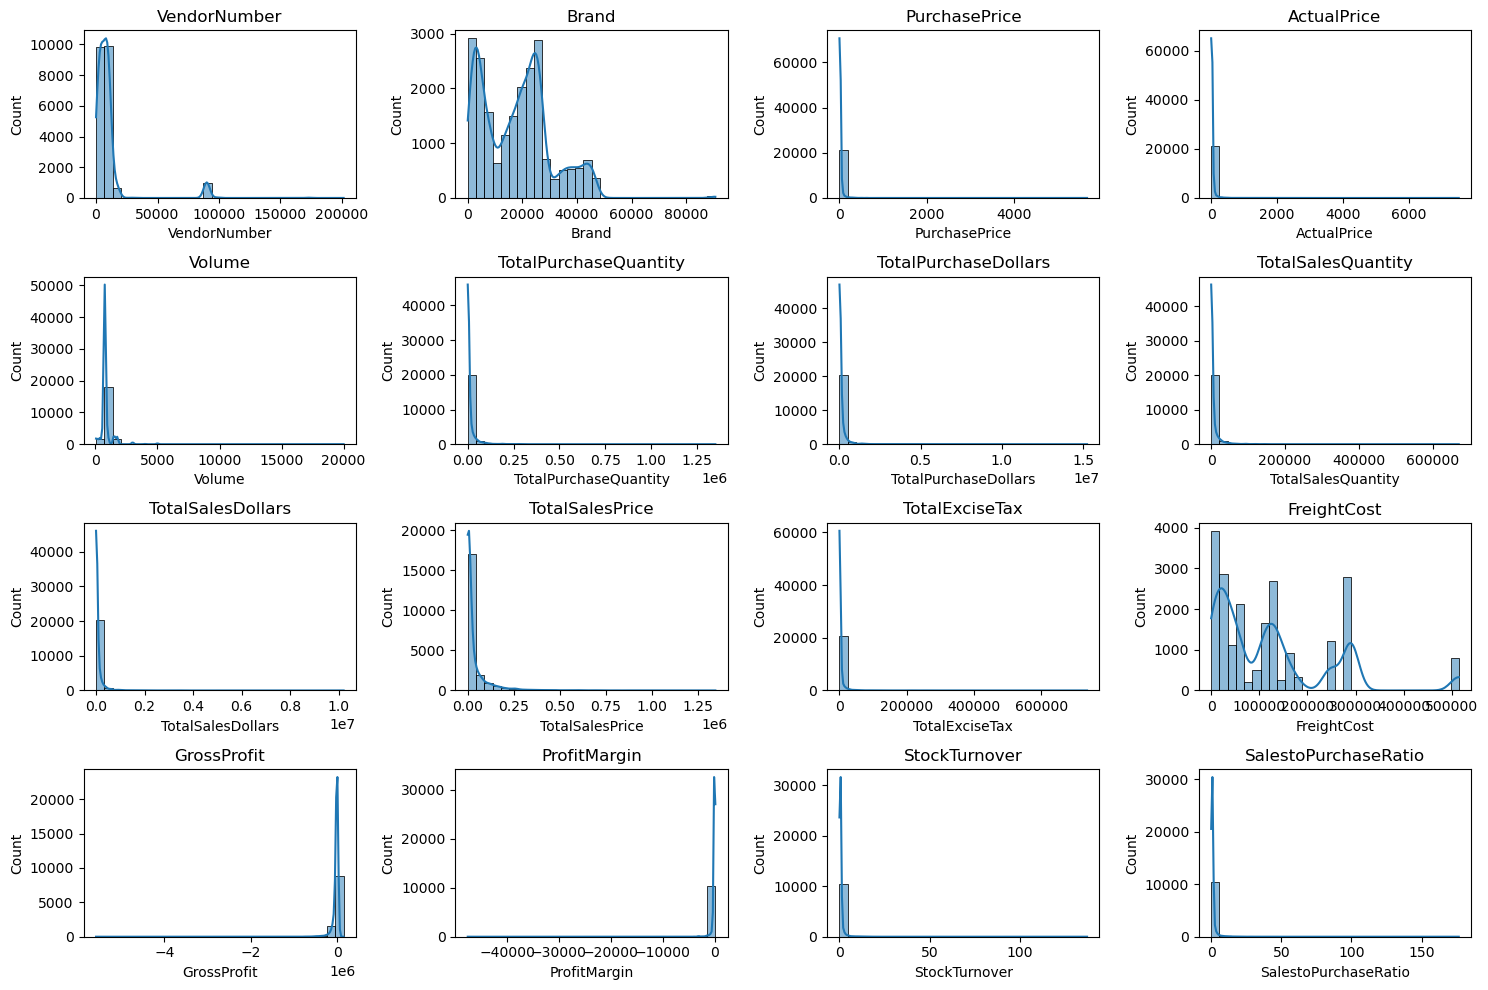

In [6]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

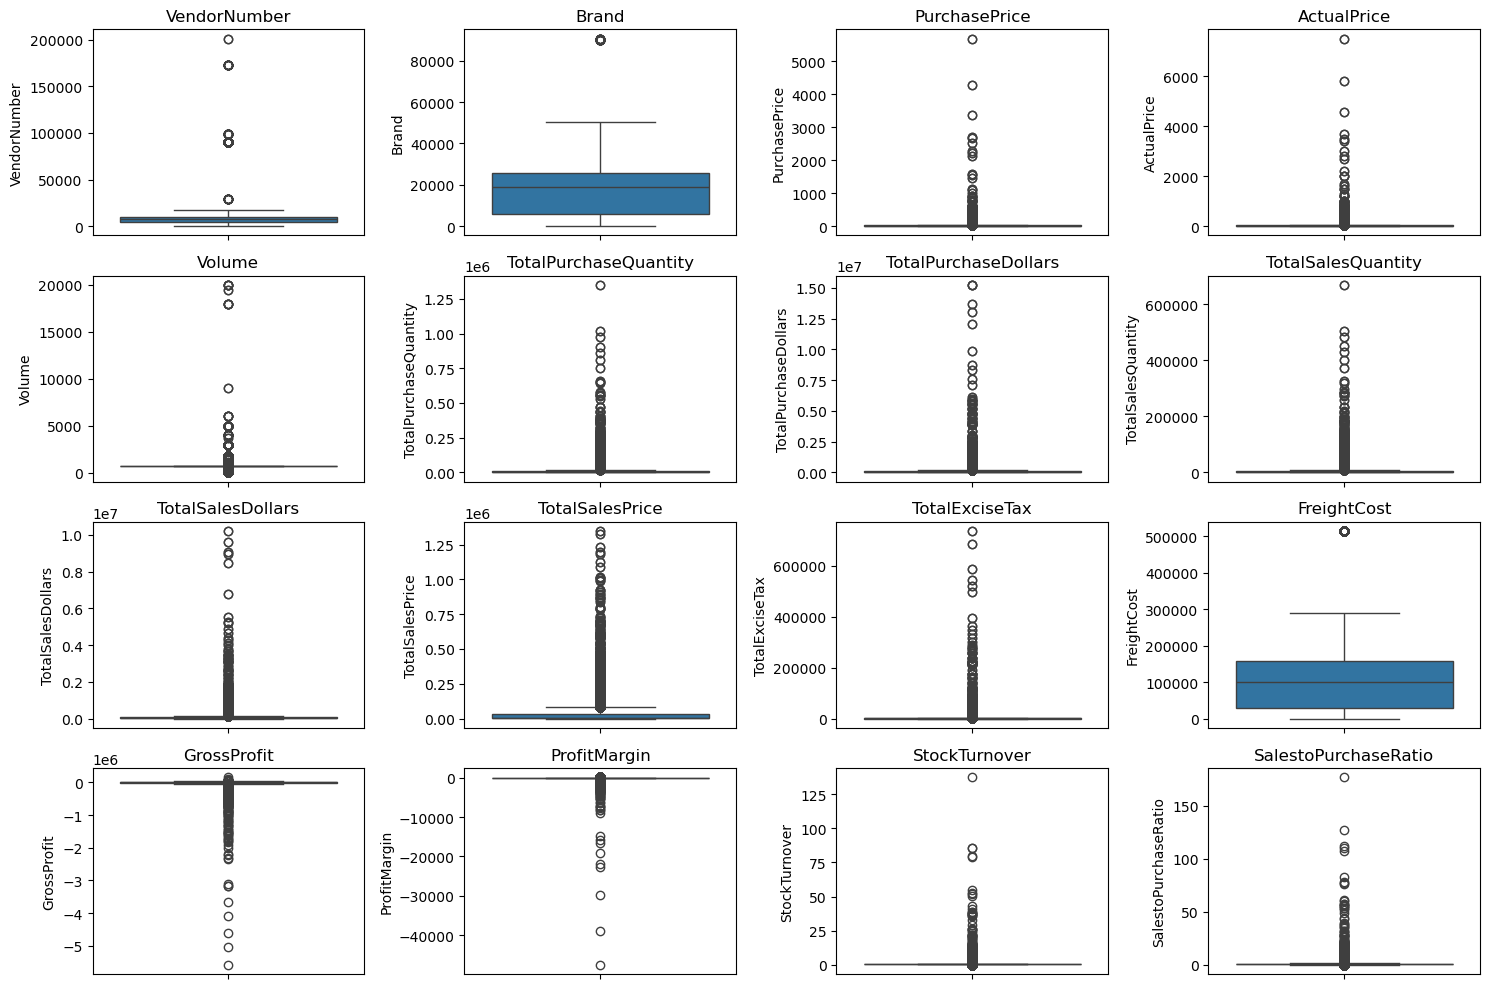

In [7]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insights:

**Negative & Zero Values:**
- **Gross Profit:** Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..
- **Profit Margin:** Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
- **Total Sales Quantity & Sales Dollars:** Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

**Outliers Indicated by High Standard Deviations:**
- **Purchase & Actual Prices:** The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
- **Freight Cost:** Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- **Stock Turnover:** Ranges from 0 to 274.5, implying some products sell extremely fast whi

In [8]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", conn)

In [9]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,4425,MARTIGNETTI COMPANIES,6983,J Lohr Seven Oaks Cab Svgn,8.27,11.99,750.0,94304,779894.08,51406.0,816295.94,263413.78,5752.48,289858.48,36401.86,4.459395,0.545109,1.046675
1,7153,PINE STATE TRADING CO,44228,Clean Slate Rsl Mosel,5.59,10.99,750.0,58508,327059.72,31436.0,333037.14,139279.10,3507.30,31769.64,5977.42,1.794821,0.537294,1.018276
2,1392,CONSTELLATION BRANDS INC,6599,Estancia Cab Svgn Paso Roble,5.78,12.99,750.0,55724,322084.72,27676.0,325406.24,132239.54,3090.56,159057.98,3321.52,1.020730,0.496662,1.010313
3,1392,CONSTELLATION BRANDS INC,15229,The Prisoner Red Napa Valley,26.11,40.99,750.0,11748,306740.28,8288.0,355137.12,184966.92,921.74,159057.98,48396.84,13.627649,0.705482,1.157778
4,4425,MARTIGNETTI COMPANIES,24786,Opus One 12,159.73,245.99,750.0,1748,279208.04,1278.0,317927.22,86080.54,143.54,289858.48,38719.18,12.178630,0.731121,1.138675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1771,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,8,11.36,28.0,55.72,11.94,1.46,514064.14,44.36,79.612347,3.500000,4.904930
1772,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,8,10.56,10.0,31.90,21.92,1.10,54200.82,21.34,66.896552,1.250000,3.020833
1773,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,24,9.36,268.0,131.32,2.94,14.08,100587.24,121.96,92.872373,11.166667,14.029915
1774,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,4,5.88,144.0,286.56,155.22,30.24,514064.14,280.68,97.948074,36.000000,48.734694


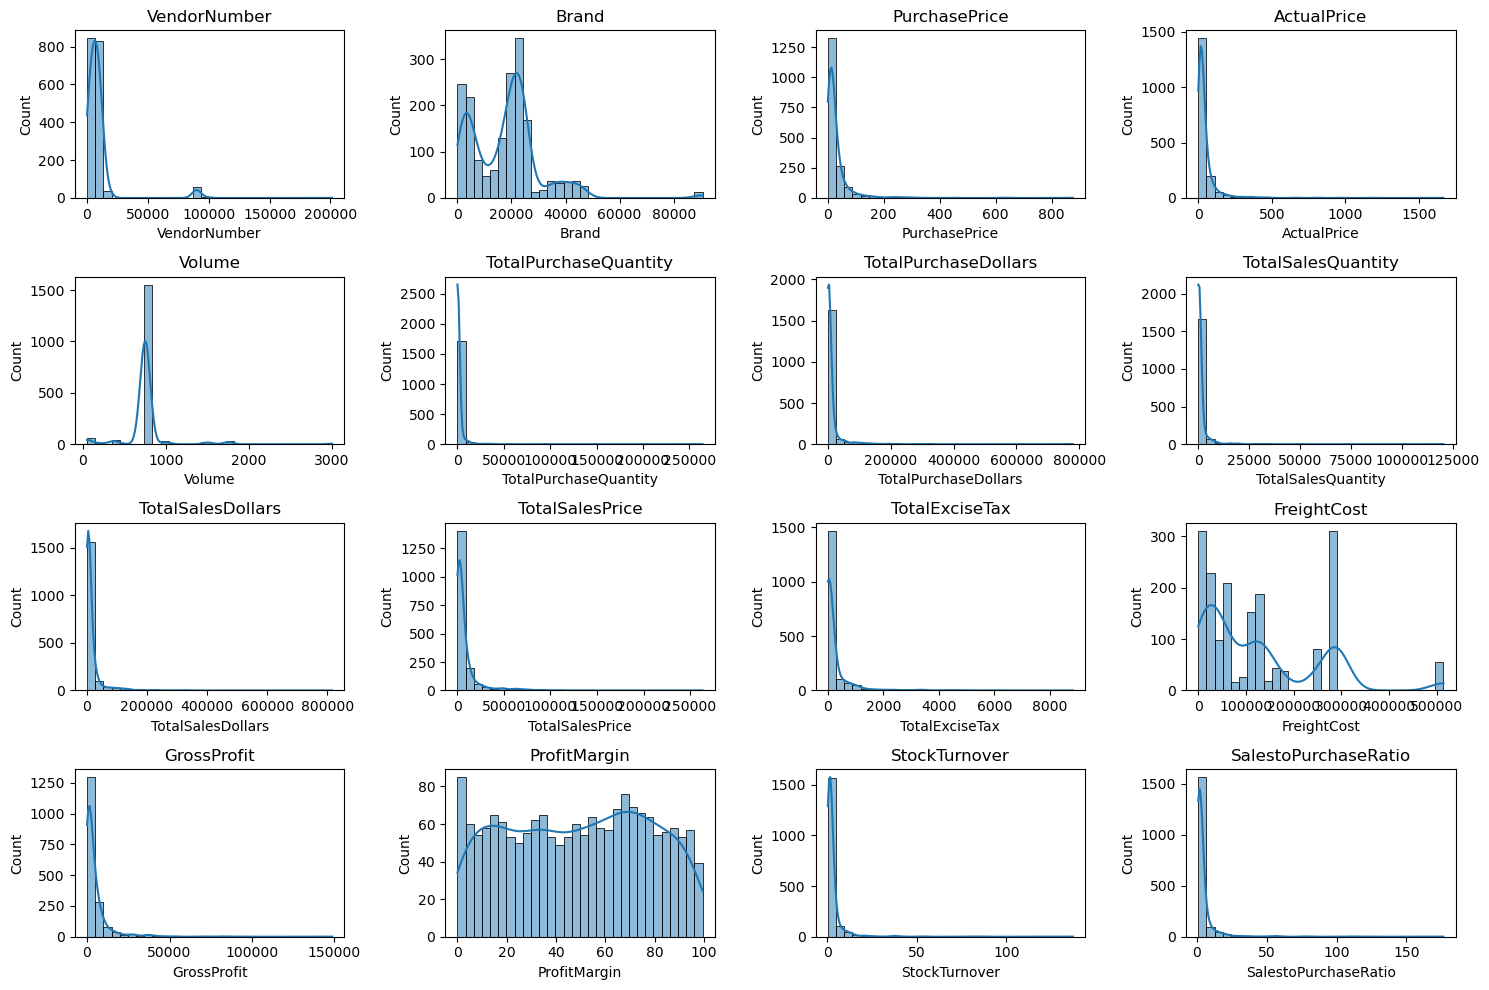

In [10]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

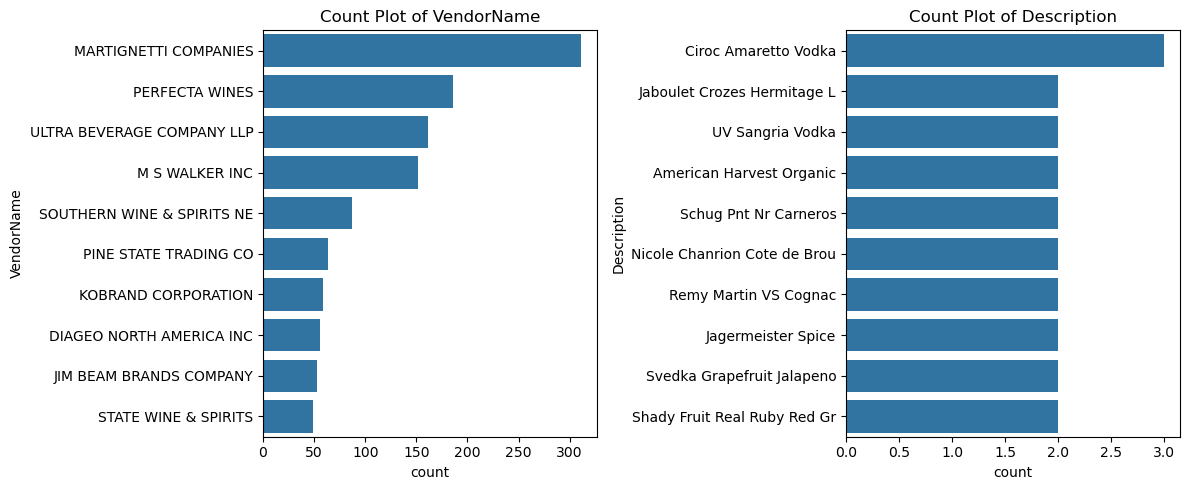

In [11]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

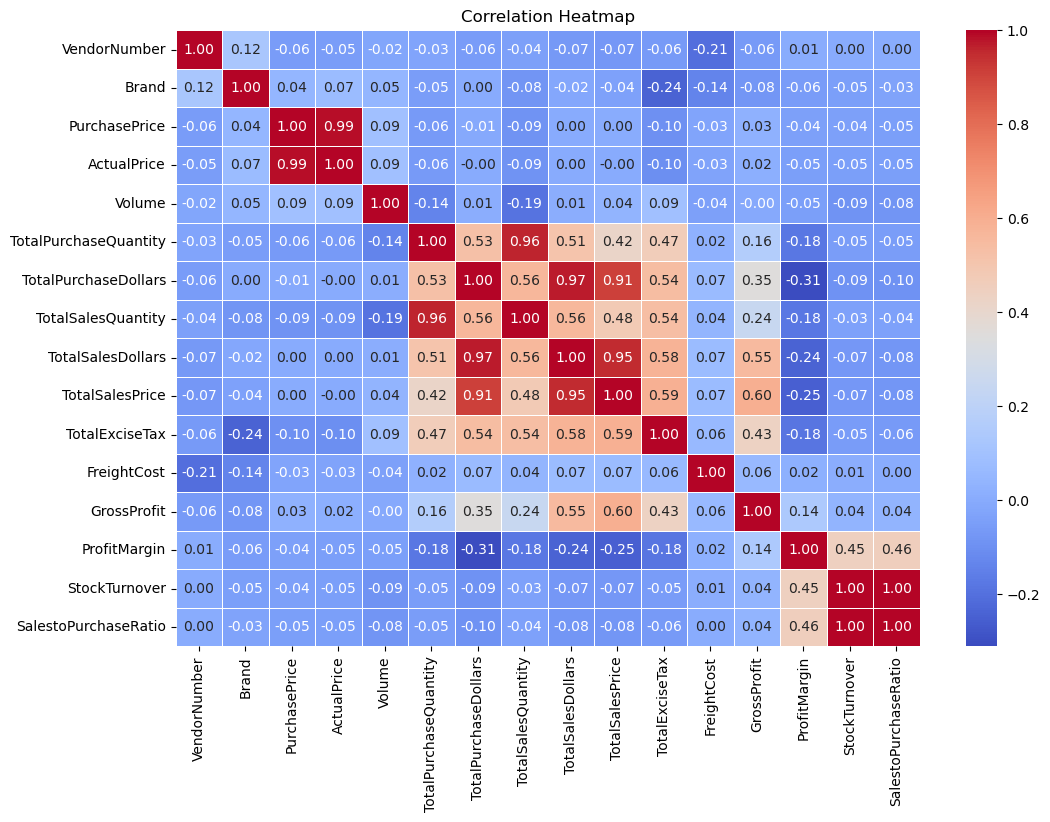

In [12]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Correlation Insights

- PurchasePrice has weak correlations with TotalSalesDollars (0.00) and GrossProfit (0.03), suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlation between total purchase quantity and total sales quantity (0.96), confirming efficient inventory turnover.
- Negative correlation between profit margin & total sales price (-0.25) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
- StockTurnover has weak correlations with both GrossProfit (0.04) and ProfitMargin (0.45), indicating that faster turnover does not necessarily result in higher profitability.

## DATA ANALYSIS

Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins

In [14]:
df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

,Description,TotalSalesDollars,ProfitMargin
0,12 Days of Pearls Gift Set,619.38,95.356647
1,13 Celsius Svgn Bl,68082.46,15.339957
2,1800 Select Silver Tequila,4258.58,78.891555
3,20 Mile 09 Brdx Superior,3898.96,67.538010
4,3 Blind Moose Cab Svgn Cal,12688.94,10.160502
...,...,...,...
1740,Zhenka Vodka 80 Proof,480.78,74.607929
1741,Zinsane Znfdl Lodi,29578.98,96.763107
1742,Zion Dolev Muscato,2659.58,44.550643
1743,Zorah Red,835.62,35.118834


In [18]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'}).reset_index()

In [25]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [26]:
low_sales_threshold

np.float64(970.1519999999998)

In [27]:
high_margin_threshold

np.float64(82.48640456102117)

In [28]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
668,Dr McGillicuddy's Apple Pie,131.32,92.872373
1313,Promesses de France CdRhone,143.82,84.675289
1585,The Club Mudslide,167.16,82.651352
1605,Three Olives Grape Vodka,170.28,98.332159
71,Aresti Pnt Nr Curico Vly,189.62,93.080899
1586,The Club Strawbry Margarita,286.56,97.948074
1273,Piehole Apple Pie,312.84,94.476410
1361,Riunite Sweet White,323.46,94.929821
1409,Sauza Sparkling Margarita,335.52,93.586075
609,DeKuyper Buttershots Trav,351.68,91.878981


In [30]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] # for better visualization

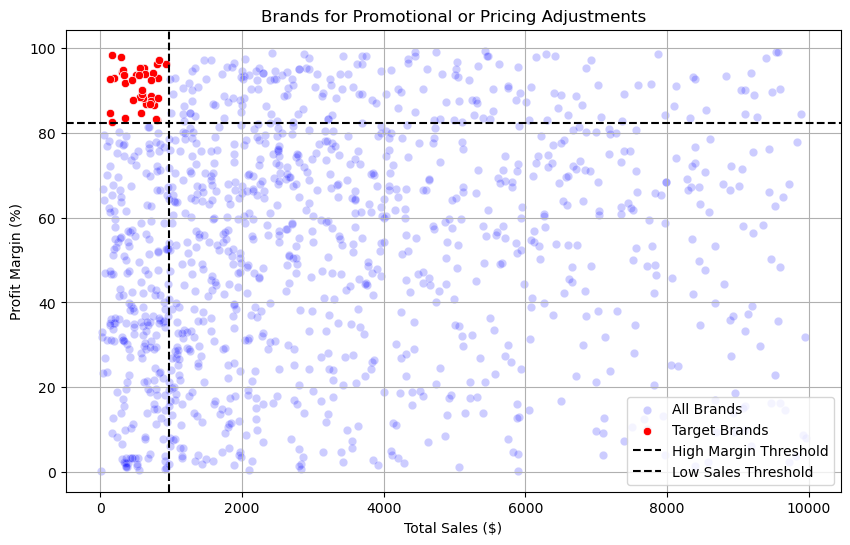

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

**Which vendors and brands demonstrate the highest sales performance?**

In [34]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [35]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
MARTIGNETTI COMPANIES         6412692.64
ULTRA BEVERAGE COMPANY LLP    2693280.08
CONSTELLATION BRANDS INC      1783370.88
PERFECTA WINES                1675388.08
M S WALKER INC                1356303.50
MOET HENNESSY USA INC          959495.66
DIAGEO NORTH AMERICA INC       931351.66
BACARDI USA INC                818662.72
SOUTHERN WINE & SPIRITS NE     764417.36
PINE STATE TRADING CO          705372.62
Name: TotalSalesDollars, dtype: float64

In [36]:
top_brands

Description
J Lohr Seven Oaks Cab Svgn      816295.94
The Prisoner Red Napa Valley    355137.12
Clean Slate Rsl Mosel           333037.14
Estancia Cab Svgn Paso Roble    325406.24
Opus One 12                     317927.22
Grand Marnier                   278829.46
WhistlePig 10 Yr Old Rye        257544.86
Jadot Macon Villages Blanc      240248.68
Acumen Moutainside Red Napa     229658.10
Hennessey VS +VSOP 50mL         226447.94
Name: TotalSalesDollars, dtype: float64

In [38]:
top_brands.apply(lambda x : format_dollars(x))

Description
J Lohr Seven Oaks Cab Svgn      816.30K
The Prisoner Red Napa Valley    355.14K
Clean Slate Rsl Mosel           333.04K
Estancia Cab Svgn Paso Roble    325.41K
Opus One 12                     317.93K
Grand Marnier                   278.83K
WhistlePig 10 Yr Old Rye        257.54K
Jadot Macon Villages Blanc      240.25K
Acumen Moutainside Red Napa     229.66K
Hennessey VS +VSOP 50mL         226.45K
Name: TotalSalesDollars, dtype: object

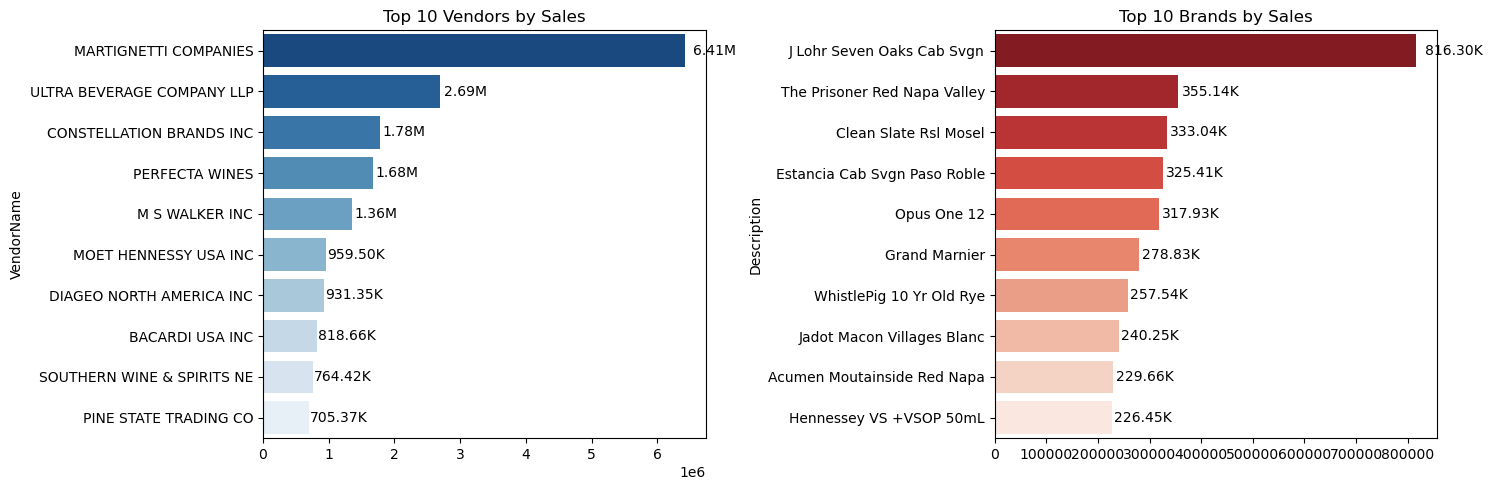

In [39]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

**Which vendors contribute the most to total purchase dollars?**

In [59]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()
vendor_performance.shape

(84, 4)

In [78]:
vendor_performance['Purchase_Contribution%'] = (vendor_performance['TotalPurchaseDollars']/ vendor_performance['TotalPurchaseDollars'].sum())*100

In [79]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_Contribution%
38,MARTIGNETTI COMPANIES,4696431.52,1716261.12,6412692.64,25.433730
75,ULTRA BEVERAGE COMPANY LLP,1784149.32,909130.76,2693280.08,9.662139
10,CONSTELLATION BRANDS INC,1553669.32,229701.56,1783370.88,8.413964
48,PERFECTA WINES,990719.92,684668.16,1675388.08,5.365287
42,MOET HENNESSY USA INC,786495.16,173000.50,959495.66,4.259299
...,...,...,...,...,...
62,SILVER MOUNTAIN CIDERS,308.72,376.30,685.02,0.001672
7,CAPSTONE INTERNATIONAL,218.56,275.18,493.74,0.001184
17,DUGGANS DISTILLED PRODUCTS,139.08,288.66,427.74,0.000753
41,MILTONS DISTRIBUTING CO,127.92,159.72,287.64,0.000693


In [80]:
vendor_performance = round(vendor_performance.sort_values('Purchase_Contribution%', ascending = False),2)

In [81]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_Contribution%
38,MARTIGNETTI COMPANIES,4.70M,1.72M,6.41M,25.43
75,ULTRA BEVERAGE COMPANY LLP,1.78M,909.13K,2.69M,9.66
10,CONSTELLATION BRANDS INC,1.55M,229.70K,1.78M,8.41
48,PERFECTA WINES,990.72K,684.67K,1.68M,5.37
42,MOET HENNESSY USA INC,786.50K,173.00K,959.50K,4.26
36,M S WALKER INC,698.15K,658.15K,1.36M,3.78
15,DIAGEO NORTH AMERICA INC,658.62K,272.73K,931.35K,3.57
51,PINE STATE TRADING CO,548.22K,157.15K,705.37K,2.97
19,E & J GALLO WINERY,502.94K,82.93K,585.88K,2.72
3,BANFI PRODUCTS CORP,461.01K,61.16K,522.17K,2.50


In [82]:
top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_Contribution%,Cumulative_Contribution%
38,MARTIGNETTI COMPANIES,4.70M,1.72M,6.41M,25.43,25.43
75,ULTRA BEVERAGE COMPANY LLP,1.78M,909.13K,2.69M,9.66,35.09
10,CONSTELLATION BRANDS INC,1.55M,229.70K,1.78M,8.41,43.50
48,PERFECTA WINES,990.72K,684.67K,1.68M,5.37,48.87
42,MOET HENNESSY USA INC,786.50K,173.00K,959.50K,4.26,53.13
36,M S WALKER INC,698.15K,658.15K,1.36M,3.78,56.91
15,DIAGEO NORTH AMERICA INC,658.62K,272.73K,931.35K,3.57,60.48
51,PINE STATE TRADING CO,548.22K,157.15K,705.37K,2.97,63.45
19,E & J GALLO WINERY,502.94K,82.93K,585.88K,2.72,66.17
3,BANFI PRODUCTS CORP,461.01K,61.16K,522.17K,2.50,68.67


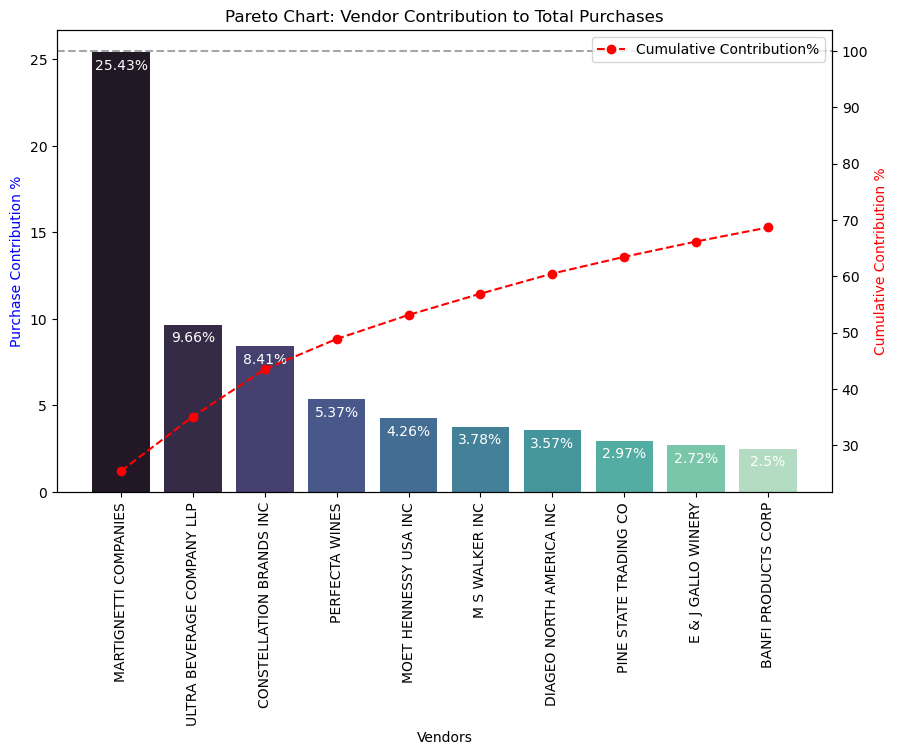

In [83]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['Purchase_Contribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative Contribution%')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

**How much of total procurement is dependent on the top vendors?**

In [84]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['Purchase_Contribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 68.67 %


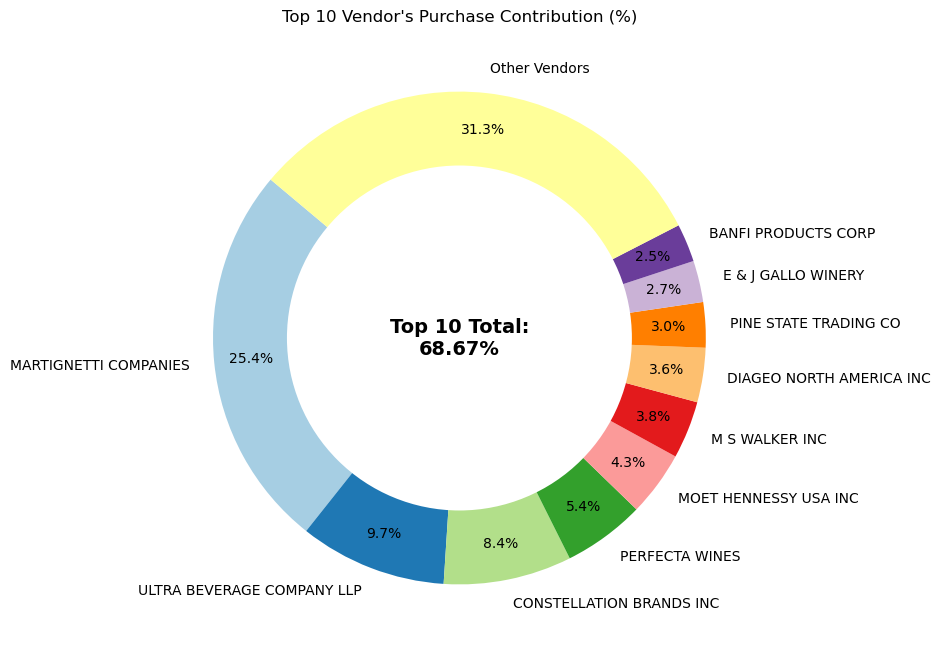

In [85]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['Purchase_Contribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                   startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

**Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?**

In [86]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df ['TotalPurchaseQuantity']

In [90]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [92]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,94304
1,Large,58508
2,Large,55724
3,Large,11748
4,Large,1748
...,...,...
1771,Small,8
1772,Small,8
1773,Small,24
1774,Small,4


In [93]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,46.787329
Medium,27.817941
Large,12.698844


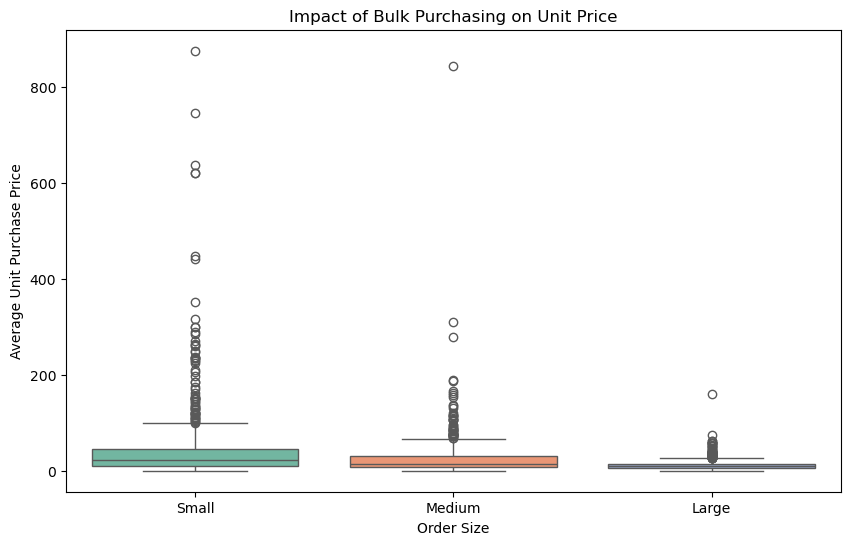

In [94]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Vendors buying in bulk (Large Order Size) get the lowest unit price ($12.70 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial 
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

**Which vendors ahve low inventory turnover, indicating excess stock and slow-moving products?**

In [99]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending = True).head(10)

,StockTurnover
VendorName,
BROWN-FORMAN CORP,0.393983
WINE GROUP INC,0.496544
JEWELL TOWNE VINEYARDS,0.570007
CHARLES JACQUIN ET CIE INC,0.586178
CRUSH WINES,0.591196
THE IMPORTED GRAPE LLC,0.604167
PALM BAY INTERNATIONAL INC,0.610052
E & J GALLO WINERY,0.611842
VINILANDIA USA,0.615593


**How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?**

In [100]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 1.14M


In [101]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
38,MARTIGNETTI COMPANIES,829.50K
10,CONSTELLATION BRANDS INC,503.71K
19,E & J GALLO WINERY,164.55K
42,MOET HENNESSY USA INC,163.66K
3,BANFI PRODUCTS CORP,156.22K
51,PINE STATE TRADING CO,121.82K
14,DIAGEO CHATEAU ESTATE WINES,105.45K
25,FREDERICK WILDMAN & SONS,90.12K
73,TREASURY WINE ESTATES,83.34K
58,SAZERAC CO INC,51.73K


**What is the 95% confidence intervals for profit margins of top-permorfing and low-performing vendors?**

In [102]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [103]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()


In [104]:
top_vendors

0        4.459395
1        1.794821
2        1.020730
3       13.627649
4       12.178630
          ...    
1020    94.675817
1094    96.763107
1157    96.891545
1352    96.669680
1532    98.367127
Name: ProfitMargin, Length: 444, dtype: float64

In [105]:
low_vendors

914      2.538529
936     14.925581
937     13.755840
945      3.028915
956      1.938227
          ...    
1771    79.612347
1772    66.896552
1773    92.872373
1774    97.948074
1775    98.332159
Name: ProfitMargin, Length: 444, dtype: float64

In [106]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (33.49, 38.58), Mean: 36.04
Low Vendors 95% CI: (45.31, 50.45), Mean: 47.88


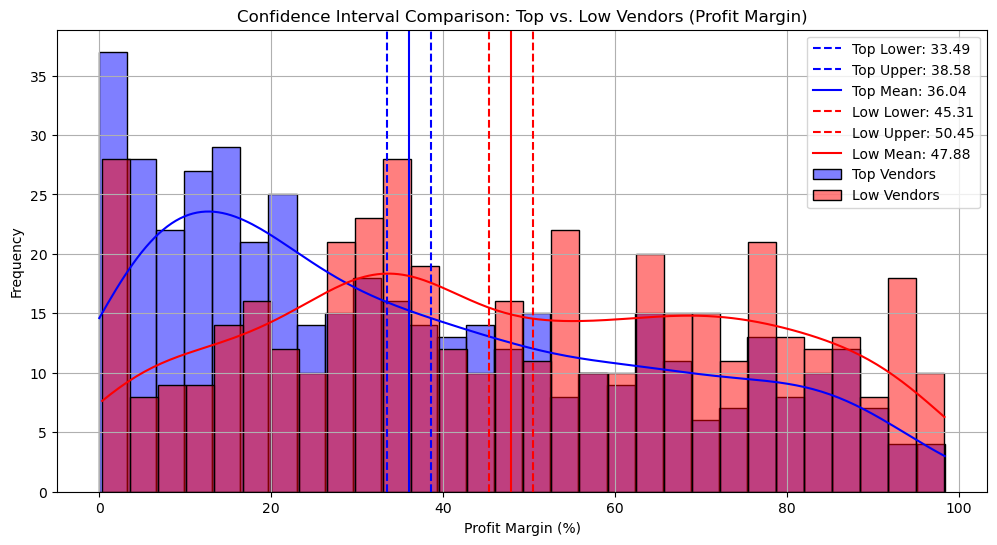

In [107]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

- The confidence interval for low-performing vendors (45.31% to 50.45%) is significantly higher than that of top-performing vendors (33.49% to 38.58%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

#### Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:

H₀ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [109]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -6.4378, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.
